In [1]:
from pathlib import Path

import numpy as np
import ovrlpy
import pandas as pd
import polars as pl

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/COSMX/Lung5_Rep1/Lung5_Rep1-Flat_files_and_images"
)

transcript_file = data_folder / "Lung5_Rep1_tx_file.csv"
cell_meta_file = data_folder / "Lung5_Rep1_metadata_file.csv"

In [3]:
transcripts = ovrlpy.io.read_CosMx(
    transcript_file, additional_columns=["cell_ID", "CellComp"]
)

transcripts = transcripts.with_columns(pl.col("CellComp").cast(pl.Categorical))
transcripts = transcripts.with_columns(pl.col("z") - pl.col("z").min())

In [4]:
scale = 0.12028  # px scale in CosMx
origin = np.array([transcripts["x"].min(), transcripts["y"].min()])

In [5]:
nsclc = ovrlpy.Ovrlp(transcripts, n_workers=16, random_state=42)
nsclc.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 9830 pseudocells
sampling expression:


100%|██████████| 9/9 [00:21<00:00,  2.44s/it]


Modeling 30 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 42/42 [03:08<00:00,  4.49s/it]


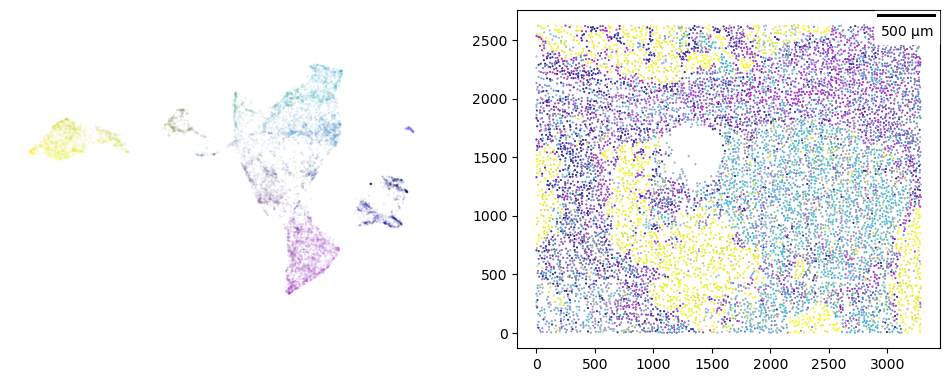

In [6]:
_ = ovrlpy.plot_pseudocells(nsclc)

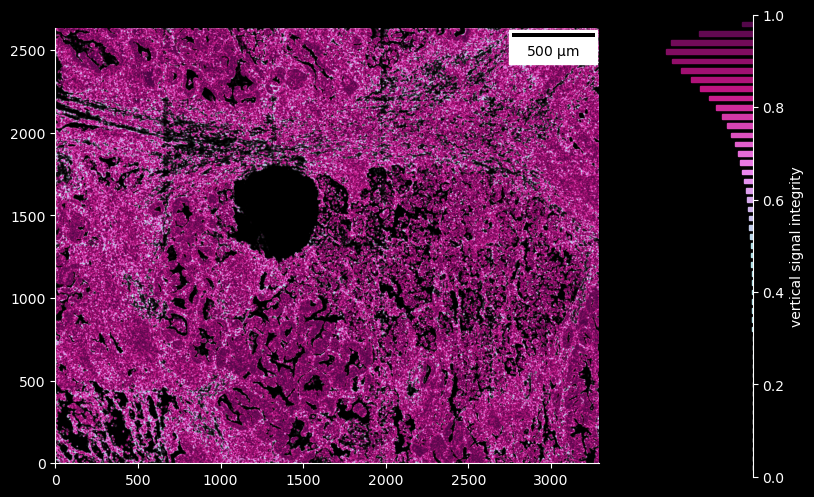

In [7]:
_ = ovrlpy.plot_signal_integrity(nsclc)

In [8]:
cell_of_interest = [
    "c_1_26_535",
    "c_1_26_1715",
    "c_1_26_2875",
]

From the [Kharchenko lab paper](https://www.biorxiv.org/content/10.1101/2025.01.02.631135v1) according to the Methods they used patient 5 Rep 1 therefore we interpret the cell ids in the paper to mean

c_1_26_1715 -> Rep 1 - fov 26 - cell_ID 1715

In [9]:
cell_meta = pd.read_csv(cell_meta_file)
cell_meta.index = (
    "c_1_" + cell_meta["fov"].astype(str) + "_" + cell_meta["cell_ID"].astype(str)
)

In [10]:
cell_loc = cell_meta.loc[
    cell_of_interest[1], ["CenterX_global_px", "CenterY_global_px"]
].to_numpy()
cell_loc = (cell_loc * scale) - origin

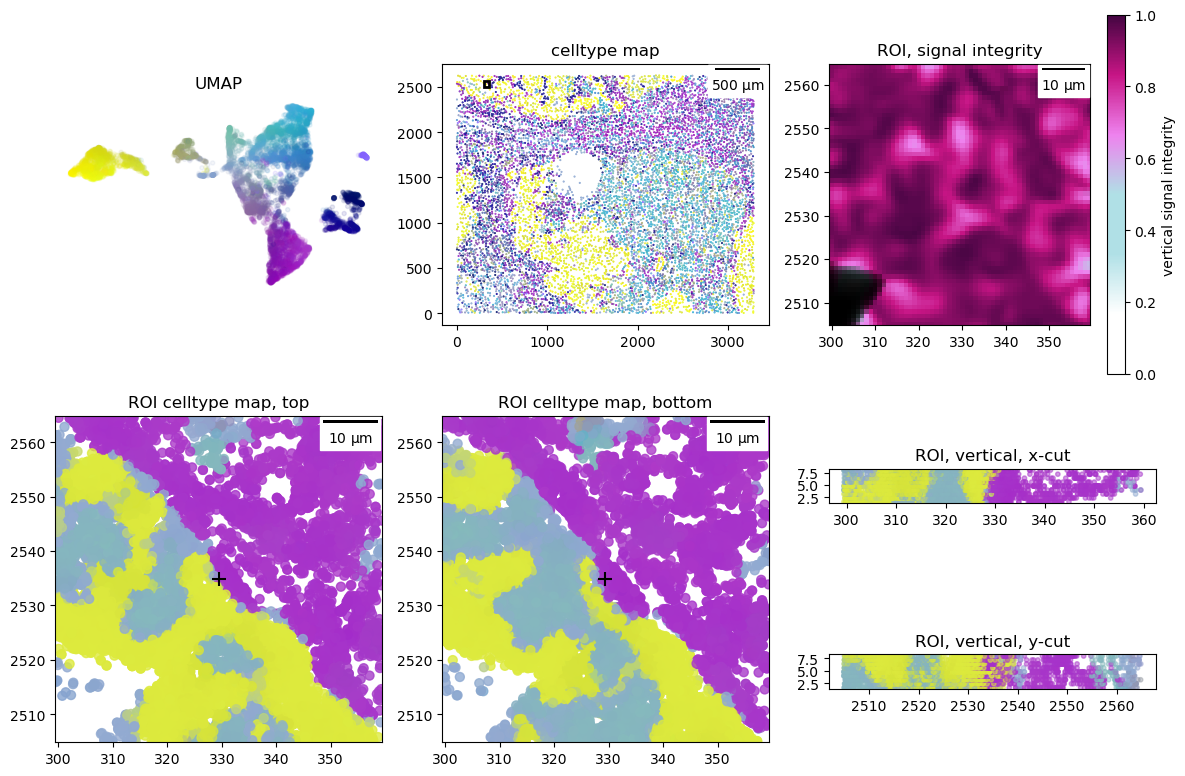

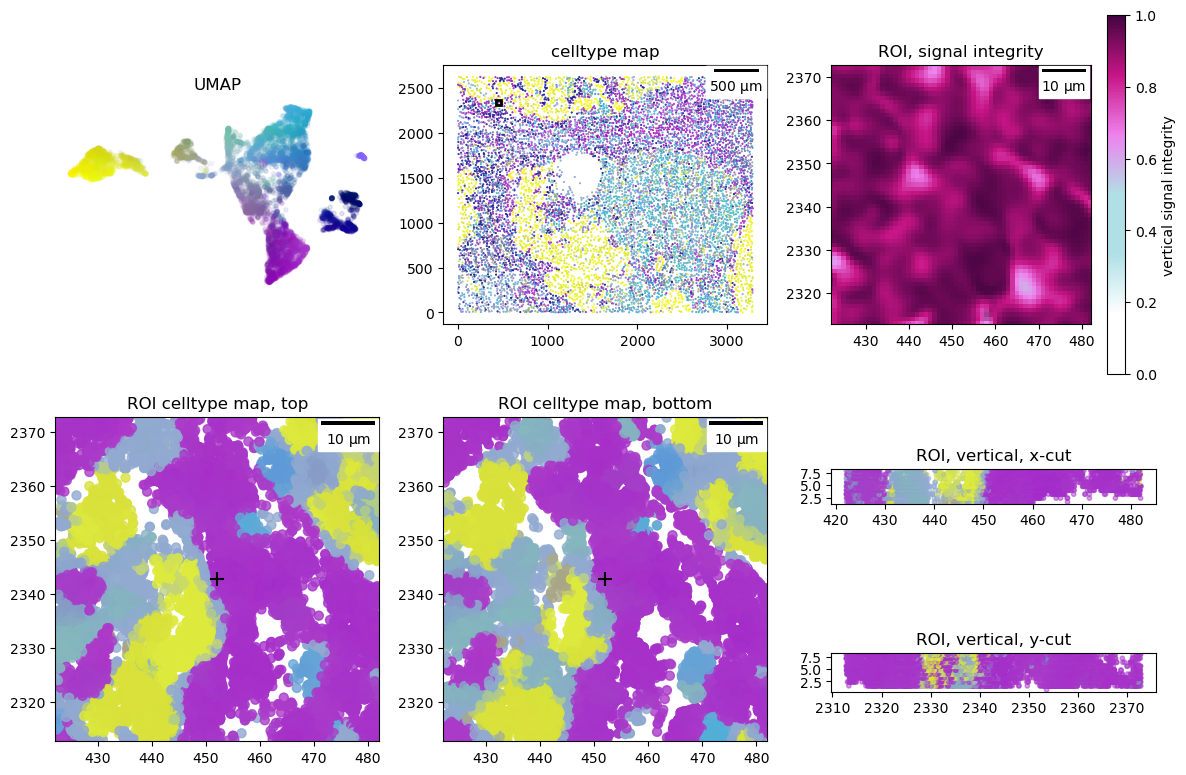

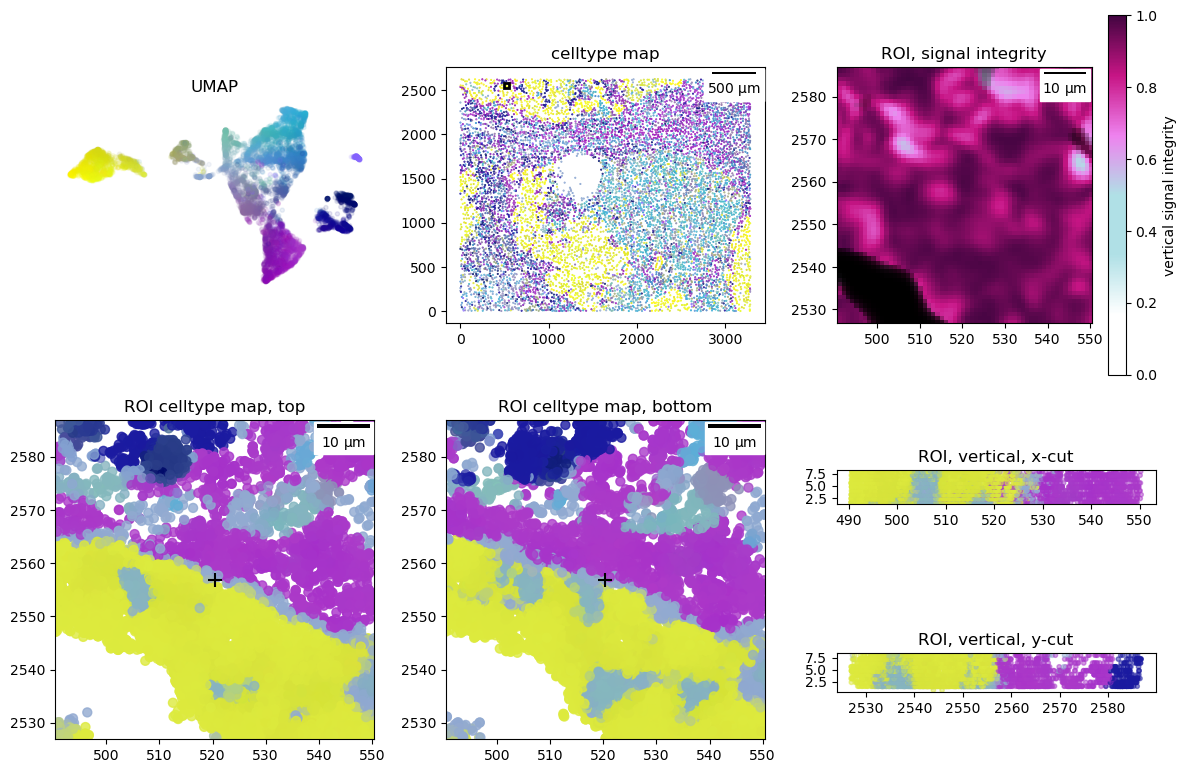

In [11]:
for cell in cell_of_interest:
    cell_loc = cell_meta.loc[
        cell, ["CenterX_global_px", "CenterY_global_px"]
    ].to_numpy()
    cell_loc = (cell_loc * scale) - origin
    ovrlpy.plot_region_of_interest(nsclc, *cell_loc)

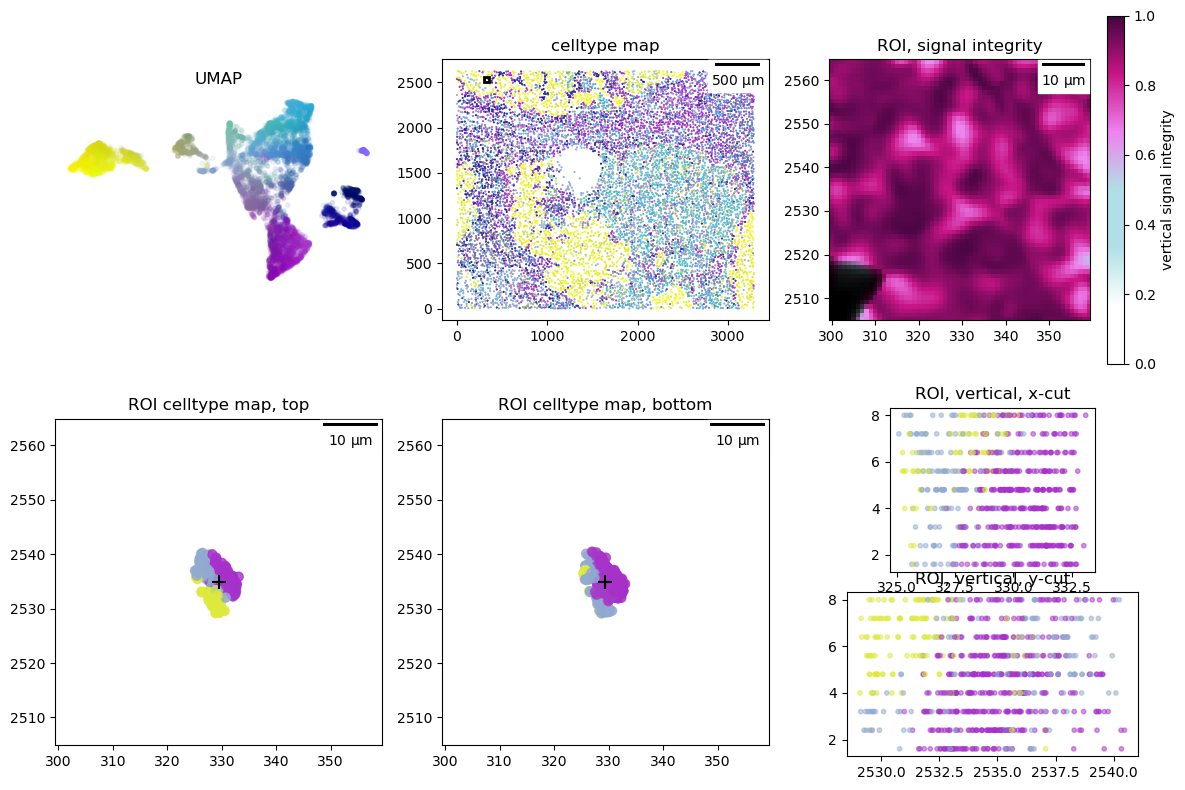

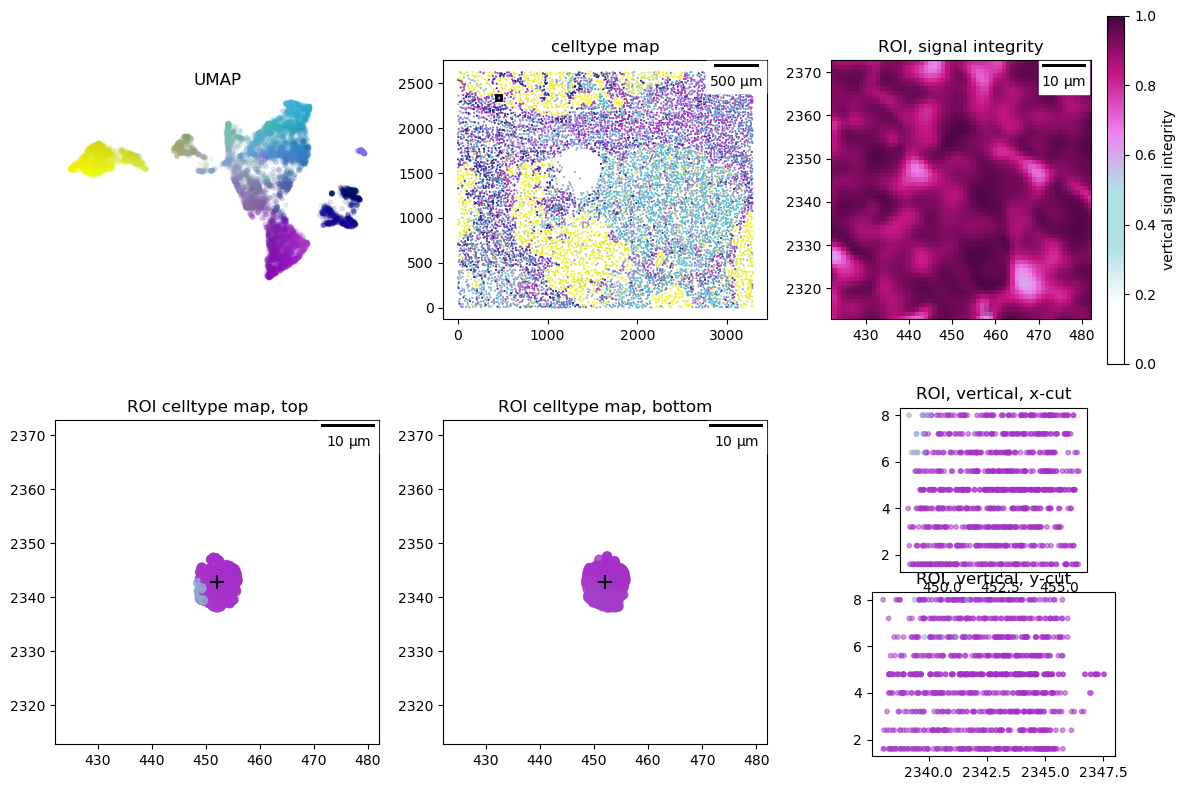

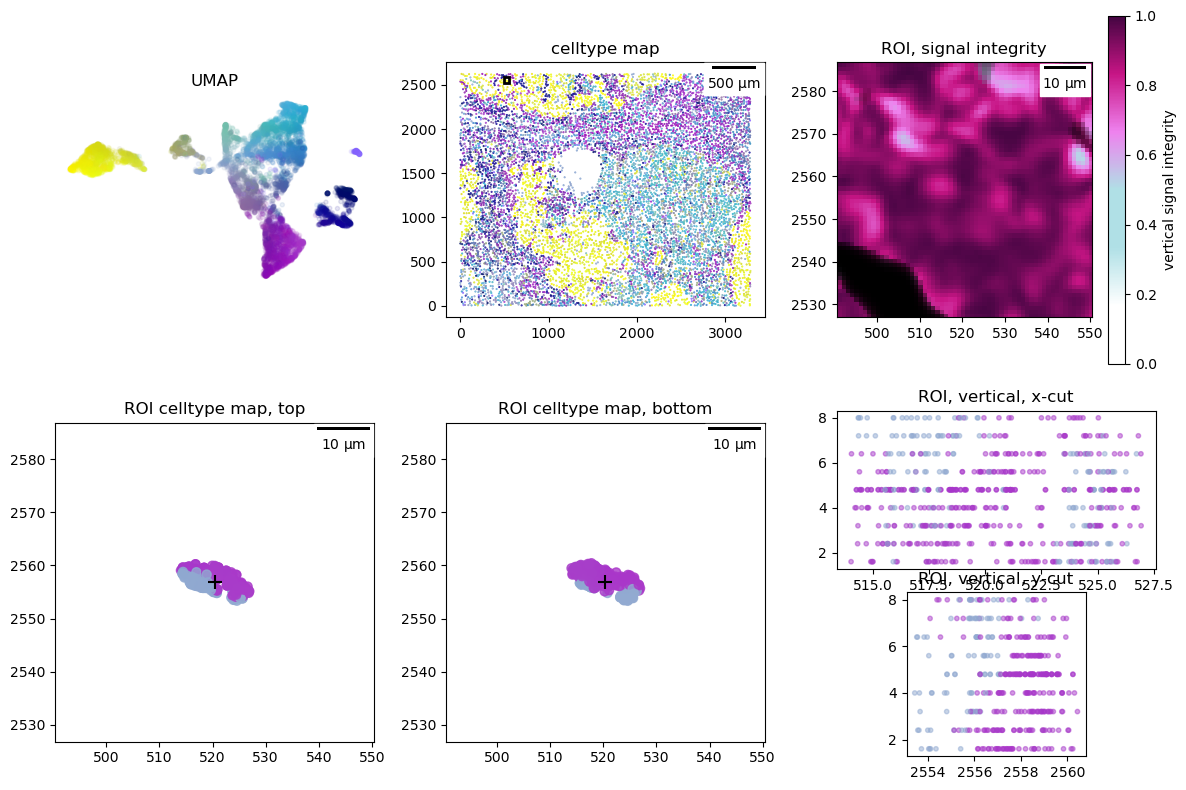

In [12]:
# only transcripts of respective cell
tr_backup = nsclc.transcripts

for cell in cell_of_interest:
    cell_id = cell_meta.at[cell, "cell_ID"]
    cell_loc = cell_meta.loc[
        cell, ["CenterX_global_px", "CenterY_global_px"]
    ].to_numpy()
    cell_loc = (cell_loc * scale) - origin

    # only keep transcripts from respective cell
    nsclc.transcripts = tr_backup.filter(pl.col("cell_ID") == cell_id)

    ovrlpy.plot_region_of_interest(nsclc, *cell_loc)